<a href="https://colab.research.google.com/github/sm1ley68/credit-card-fraud-detection/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
size = os.path.getsize('creditcard.csv')
print(f"Размер файла на диске: {size/1024/1024:.1f} МБ")
print("Ожидаем ~144 МБ. Если меньше — файл на диске битый, читать бесполезно.")

Размер файла на диске: 143.8 МБ
Ожидаем ~144 МБ. Если меньше — файл на диске битый, читать бесполезно.


In [16]:
import os
for f in os.listdir('.'):
    if 'creditcard' in f:
        size = os.path.getsize(f) / 1024 / 1024
        print(f"{f}  —  {size:.1f} МБ")

creditcard.csv  —  143.8 МБ


In [17]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape, "| мошенников:", int(df['Class'].sum()))

Shape: (284807, 31) | мошенников: 492


In [18]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
print("Абсолютные числа:")
print(df['Class'].value_counts())
print()
print("Доли:")
print(df['Class'].value_counts(normalize=True))

Абсолютные числа:
Class
0    284315
1       492
Name: count, dtype: int64

Доли:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [20]:
na_counts = df.isnull().sum()
print(na_counts[na_counts > 0])
print()
print("Всего строк с хотя бы одним NaN:", df.isnull().any(axis=1).sum())

Series([], dtype: int64)

Всего строк с хотя бы одним NaN: 0


In [21]:
df[df.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [22]:
import matplotlib.pyplot as plt

# Amount: сравним суммы транзакций у честных и мошенников
print("=== Amount: статистика по классам ===")
print(df.groupby('Class')['Amount'].describe())

=== Amount: статистика по классам ===
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


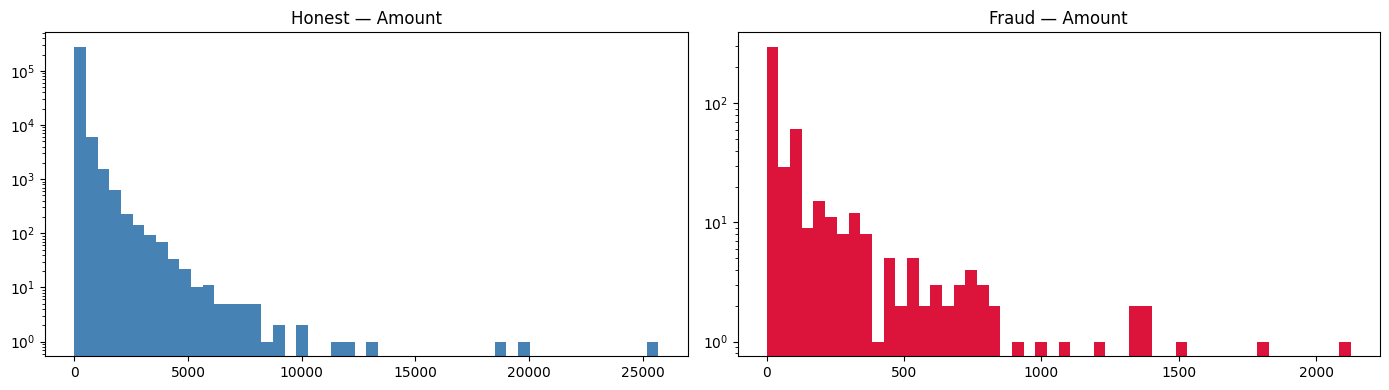

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, color='steelblue')
axes[0].set_title('Honest — Amount')
axes[0].set_yscale('log')

axes[1].hist(df[df['Class']==1]['Amount'], bins=50, color='crimson')
axes[1].set_title('Fraud — Amount')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [24]:
v_cols = [c for c in df.columns if c.startswith('V')]

diff = df.groupby('Class')[v_cols].mean().T
diff.columns = ['honest_mean', 'fraud_mean']
diff['abs_diff'] = (diff['fraud_mean'] - diff['honest_mean']).abs()

# Топ-10 фич с самым большим разрывом средних
print(diff.sort_values('abs_diff', ascending=False).head(10))

     honest_mean  fraud_mean  abs_diff
V3      0.012171   -7.033281  7.045452
V14     0.012064   -6.971723  6.983787
V17     0.011535   -6.665836  6.677371
V12     0.010832   -6.259393  6.270225
V10     0.009824   -5.676883  5.686707
V7      0.009637   -5.568731  5.578368
V1      0.008258   -4.771948  4.780206
V4     -0.007860    4.542029  4.549889
V16     0.007164   -4.139946  4.147110
V11    -0.006576    3.800173  3.806749


In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # доля мошенников одинакова в train и test
    random_state=42    # воспроизводимость
)

print("Train:", X_train.shape, "| мошенников:", int(y_train.sum()),
      "| доля:", round(y_train.mean(), 6))
print("Test: ", X_test.shape, "| мошенников:", int(y_test.sum()),
      "| доля:", round(y_test.mean(), 6))

Train: (227845, 30) | мошенников: 394 | доля: 0.001729
Test:  (56962, 30) | мошенников: 98 | доля: 0.00172


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              average_precision_score, roc_auc_score)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

pred = dummy.predict(X_test)
proba = dummy.predict_proba(X_test)[:, 1]

print("=== Baseline: всегда 'честный' ===")
print("Accuracy: ", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 4))
print("Recall:   ", round(recall_score(y_test, pred, zero_division=0), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, proba), 4))
print("PR-AUC:   ", round(average_precision_score(y_test, proba), 4))

=== Baseline: всегда 'честный' ===
Accuracy:  0.9983
Precision: 0.0
Recall:    0.0
ROC-AUC:   0.5
PR-AUC:    0.0017


In [27]:
!pip install lightgbm -q

from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

lgb = LGBMClassifier(random_state=42, verbose=-1)
lgb.fit(X_train, y_train)

proba = lgb.predict_proba(X_test)[:, 1]

print("=== LightGBM (дефолт) ===")
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("PR-AUC: ", round(average_precision_score(y_test, proba), 4))

=== LightGBM (дефолт) ===
ROC-AUC: 0.8203
PR-AUC:  0.3534


In [28]:
print(X_train[['Time', 'Amount']].describe())

                Time         Amount
count  227845.000000  227845.000000
mean    94885.093704      88.176298
std     47488.415034     250.722602
min         0.000000       0.000000
25%     54228.000000       5.640000
50%     84805.000000      22.000000
75%    139364.000000      77.490000
max    172792.000000   25691.160000


In [29]:
import numpy as np

# копии, чтобы не портить оригинал
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

# Amount → log1p (log(1+x), корректно работает с нулями)
X_train_fe['Amount_log'] = np.log1p(X_train_fe['Amount'])
X_test_fe['Amount_log']  = np.log1p(X_test_fe['Amount'])

# выкидываем сырые Time и Amount
X_train_fe = X_train_fe.drop(['Time', 'Amount'], axis=1)
X_test_fe  = X_test_fe.drop(['Time', 'Amount'], axis=1)

# переобучаем тот же LightGBM на новых фичах
lgb_fe = LGBMClassifier(random_state=42, verbose=-1)
lgb_fe.fit(X_train_fe, y_train)
proba_fe = lgb_fe.predict_proba(X_test_fe)[:, 1]

print("LightGBM + FE (log Amount, drop Time)")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_fe), 4))
print("PR-AUC: ", round(average_precision_score(y_test, proba_fe), 4))
print()
print("Было (дефолт): ROC-AUC 0.8203 | PR-AUC 0.3534")

LightGBM + FE (log Amount, drop Time)
ROC-AUC: 0.7211
PR-AUC:  0.1646

Было (дефолт): ROC-AUC 0.8203 | PR-AUC 0.3534


In [30]:
X_train_v2 = X_train.copy()
X_test_v2  = X_test.copy()

X_train_v2['Amount_log'] = np.log1p(X_train_v2['Amount'])
X_test_v2['Amount_log']  = np.log1p(X_test_v2['Amount'])
X_train_v2 = X_train_v2.drop(['Amount'], axis=1)
X_test_v2  = X_test_v2.drop(['Amount'], axis=1)

lgb_v2 = LGBMClassifier(random_state=42, verbose=-1)
lgb_v2.fit(X_train_v2, y_train)
proba_v2 = lgb_v2.predict_proba(X_test_v2)[:, 1]

print("Вернули Time, Amount=log")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_v2), 4))
print("PR-AUC: ", round(average_precision_score(y_test, proba_v2), 4))
print()
print("Дефолт (всё сырое):     PR-AUC 0.3534")
print("Лог + выброс Time:      PR-AUC 0.1646")

Вернули Time, Amount=log
ROC-AUC: 0.8207
PR-AUC:  0.3683

Дефолт (всё сырое):     PR-AUC 0.3534
Лог + выброс Time:      PR-AUC 0.1646


In [31]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", round(spw, 1))

lgb_w = LGBMClassifier(random_state=42, verbose=-1, scale_pos_weight=spw)
lgb_w.fit(X_train_v2, y_train)          # используем лучшую конфигурацию фич
proba_w = lgb_w.predict_proba(X_test_v2)[:, 1]

print("=== LightGBM + log Amount + scale_pos_weight ===")
print("ROC-AUC:", round(roc_auc_score(y_test, proba_w), 4))
print("PR-AUC: ", round(average_precision_score(y_test, proba_w), 4))
print()

scale_pos_weight = 577.3
=== LightGBM + log Amount + scale_pos_weight ===
ROC-AUC: 0.9061
PR-AUC:  0.0636



In [32]:
for w in [1, 5, 10, 25, 50, 100]:
    m = LGBMClassifier(random_state=42, verbose=-1, scale_pos_weight=w)
    m.fit(X_train_v2, y_train)
    p = m.predict_proba(X_test_v2)[:, 1]
    print(f"spw={w:>4} | ROC-AUC {roc_auc_score(y_test,p):.4f} | PR-AUC {average_precision_score(y_test,p):.4f}")

spw=   1 | ROC-AUC 0.8207 | PR-AUC 0.3683
spw=   5 | ROC-AUC 0.8182 | PR-AUC 0.0873
spw=  10 | ROC-AUC 0.8770 | PR-AUC 0.1176
spw=  25 | ROC-AUC 0.8908 | PR-AUC 0.1955
spw=  50 | ROC-AUC 0.8787 | PR-AUC 0.0915
spw= 100 | ROC-AUC 0.9034 | PR-AUC 0.0865


In [33]:
!pip install optuna -q
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)  # чтобы не засорять вывод

# CV-схема: 5 фолдов, стратифицированные (доля мошенников ровная в каждом фолде)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    # Optuna сама предлагает значения из заданных диапазонов
    params = {
        'random_state': 42,
        'verbose': -1,
        'device': 'gpu',
        'max_bin': 63,
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_v2, y_train,
                             cv=cv, scoring='average_precision', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)   # вдвое меньше попыток

print("Лучший CV PR-AUC:", round(study.best_value, 4))
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.6 MB/s eta 0:00:00


  0%|          | 0/20 [00:00<?, ?it/s]

Лучший CV PR-AUC: 0.8469
Лучшие параметры:
  n_estimators: 568
  learning_rate: 0.04205071580060457
  num_leaves: 140
  max_depth: 12
  min_child_samples: 85
  subsample: 0.7049776847515314
  colsample_bytree: 0.7009111518624576


In [34]:
# финальная модель на лучших параметрах
best_params = study.best_params
best_params.update({'random_state': 42, 'verbose': -1, 'device': 'gpu', 'max_bin': 63})

final_model = LGBMClassifier(**best_params)
final_model.fit(X_train_v2, y_train)

proba_test = final_model.predict_proba(X_test_v2)[:, 1]

test_pr_auc  = average_precision_score(y_test, proba_test)
test_roc_auc = roc_auc_score(y_test, proba_test)

print("ФИНАЛ на test")
print("Test PR-AUC: ", round(test_pr_auc, 4))
print("Test ROC-AUC:", round(test_roc_auc, 4))
print()
print("Для сравнения CV PR-AUC был:", round(study.best_value, 4))

ФИНАЛ на test
Test PR-AUC:  0.8874
Test ROC-AUC: 0.9753

Для сравнения CV PR-AUC был: 0.8469


In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix

# стоимость ошибок (в деньгах)
COST_FN = 122   # пропустить мошенника — теряем сумму транзакции
COST_FP = 5     # заблокировать честного — поддержка, недовольство

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []
for t in thresholds:
    pred = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fp * COST_FP + fn * COST_FN)

costs = np.array(costs)
best_t = thresholds[costs.argmin()]
print("Оптимальный порог:", round(best_t, 3))
print("Минимальные потери: $", int(costs.min()))
print("Потери при пороге 0.5: $", int(costs[np.argmin(np.abs(thresholds-0.5))]))

Оптимальный порог: 0.02
Минимальные потери: $ 1875
Потери при пороге 0.5: $ 2460


Оптимальный порог: 0.02
Минимальные потери: $ 1875


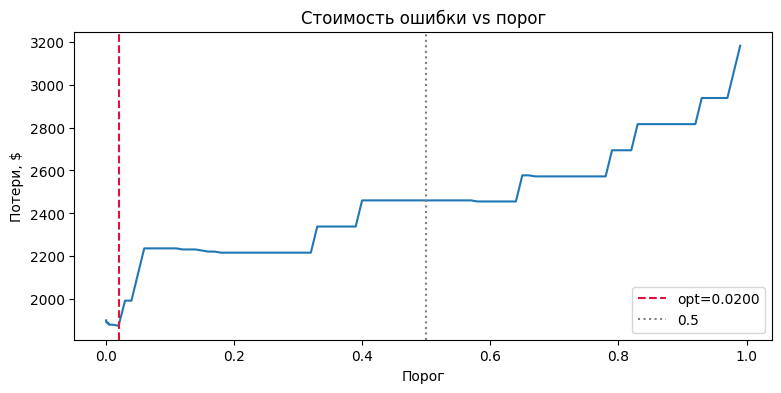

In [36]:
import matplotlib.pyplot as plt

thresholds = np.concatenate([
    np.arange(0.0005, 0.01, 0.0005),  # очень мелкие пороги
    np.arange(0.01, 1.0, 0.01)
])
costs = []
for t in thresholds:
    pred = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fp * COST_FP + fn * COST_FN)
costs = np.array(costs)

best_t = thresholds[costs.argmin()]
print("Оптимальный порог:", round(best_t, 4))
print("Минимальные потери: $", int(costs.min()))

plt.figure(figsize=(9,4))
plt.plot(thresholds, costs)
plt.axvline(best_t, color='crimson', ls='--', label=f'opt={best_t:.4f}')
plt.axvline(0.5, color='gray', ls=':', label='0.5')
plt.xlabel('Порог'); plt.ylabel('Потери, $'); plt.legend(); plt.title('Стоимость ошибки vs порог')
plt.show()

In [37]:
# сколько транзакций блокируем при пороге 0.002
pred_opt = (proba_test >= 0.002).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_opt).ravel()
print(f"Порог 0.002: поймано мошенников {tp}/{tp+fn}, ложных блокировок {fp}, всего блокировок {tp+fp}")

# а теперь с реалистичной ценой ложной блокировки (отток клиента дороже!)
for cost_fp in [5, 50, 200, 500]:
    costs = []
    for t in thresholds:
        pred = (proba_test >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        costs.append(fp*cost_fp + fn*122)
    bt = thresholds[np.argmin(costs)]
    print(f"COST_FP=${cost_fp:>3} → оптимальный порог {bt:.3f}")

Порог 0.002: поймано мошенников 83/98, ложных блокировок 12, всего блокировок 95
COST_FP=$  5 → оптимальный порог 0.020
COST_FP=$ 50 → оптимальный порог 0.020
COST_FP=$200 → оптимальный порог 0.670
COST_FP=$500 → оптимальный порог 0.670


In [44]:
import joblib, numpy as np

# финальный набор фич: log Amount, БЕЗ Time, БЕЗ сырого Amount
def make_features(X):
    X = X.copy()
    X['Amount_log'] = np.log1p(X['Amount'])
    return X.drop(['Time', 'Amount'], axis=1)

X_train_final = make_features(X_train)
X_test_final  = make_features(X_test)

deploy_params = study.best_params.copy()
deploy_params.update({'random_state': 42, 'verbose': -1})

model_final = LGBMClassifier(**deploy_params)
model_final.fit(X_train_final, y_train)

proba = model_final.predict_proba(X_test_final)[:, 1]
print("Финальный PR-AUC:", round(average_precision_score(y_test, proba), 4))

joblib.dump({
    'model': model_final,
    'columns': list(X_train_final.columns)
}, 'fraud_model.joblib')
print("Сохранено")

loaded = joblib.load('fraud_model.joblib')
p = loaded['model'].predict_proba(X_test_final)[:, 1]
print("После загрузки:", round(average_precision_score(y_test, p), 4))

Финальный PR-AUC: 0.8755
Сохранено
После загрузки: 0.8755


In [45]:
import json

# берём по 3 реальных примера каждого класса из test
fraud_idx  = y_test[y_test==1].index[:3]
honest_idx = y_test[y_test==0].index[:3]

examples = {
    'fraud':  X_test.loc[fraud_idx].to_dict('records'),
    'honest': X_test.loc[honest_idx].to_dict('records')
}

with open('examples.json', 'w') as f:
    json.dump(examples, f)
print("✅ examples.json сохранён")
print("Мошеннических примеров:", len(examples['fraud']))
print("Честных примеров:", len(examples['honest']))

✅ examples.json сохранён
Мошеннических примеров: 3
Честных примеров: 3
